In [ ]:
import pandas as pd

df = pd.read_csv("test_public.csv")

print("Dataset Loaded Successfully!")

Dataset Loaded Successfully!


In [ ]:
print("Rows, Columns:", df.shape)
print(df.columns.tolist())

Rows, Columns: (59319, 16)
[' author', 'clean_title', 'created_utc', 'domain', 'hasImage', 'id', 'image_url', 'linked_submission_id', 'num_comments', 'score', 'subreddit', 'title', 'upvote_ratio', '2_way_label', '3_way_label', '6_way_label']


In [ ]:
for col in df.columns:
    print(col)

 author
clean_title
created_utc
domain
hasImage
id
image_url
linked_submission_id
num_comments
score
subreddit
title
upvote_ratio
2_way_label
3_way_label
6_way_label


In [ ]:
print("TITLE:")
print(df["clean_title"].iloc[0])

print("\nIMAGE URL:")
print(df["image_url"].iloc[0])

print("\nLABEL:")
print(df["2_way_label"].iloc[0])

TITLE:
stargazer

IMAGE URL:
http://i.imgur.com/BruWKDi.jpg

LABEL:
0


In [ ]:
print(df["2_way_label"].value_counts())

2_way_label
0    35812
1    23507
Name: count, dtype: int64


In [ ]:
print("LABEL 0 EXAMPLES:\n")

print(df[df["2_way_label"] == 0]["clean_title"].head(5))

print("\n\nLABEL 1 EXAMPLES:\n")

print(df[df["2_way_label"] == 1]["clean_title"].head(5))

LABEL 0 EXAMPLES:

0                                            stargazer
1                                                 yeah
4                                  believers hezbollah
5                    the rise of italian fascism circa
8    look at this cool iphone case i got the other day
Name: clean_title, dtype: object


LABEL 1 EXAMPLES:

2     pd phoenix car thief gets instructions from yo...
3     as trump accuses iran he has one problem his o...
6     trumps pick to lead ice who touted surge in im...
7                                     my friend midflip
10                                     this smiling dog
Name: clean_title, dtype: object


In [ ]:
print(df["2_way_label"].unique())
print(df["3_way_label"].unique())
print(df["6_way_label"].unique())

[0 1]
[2 0 1]
[4 0 5 2 1 3]


Attempting to display image from URL: http://i.imgur.com/BruWKDi.jpg
Error fetching image from http://i.imgur.com/BruWKDi.jpg: 429 Client Error: Unknown Error for url: http://i.imgur.com/BruWKDi.jpg
Attempting to display image from URL: http://i.imgur.com/JRZT727.jpg
Error fetching image from http://i.imgur.com/JRZT727.jpg: 429 Client Error: Unknown Error for url: http://i.imgur.com/JRZT727.jpg
Attempting to display image from URL: https://external-preview.redd.it/1A2_4VwgS8Qd2L6u_G2gzPLLtUqdhPkGvLOtM704LiQ.jpg?width=320&crop=smart&auto=webp&s=2630b82b89f0370a5c680765e1da86cfaee0b68e


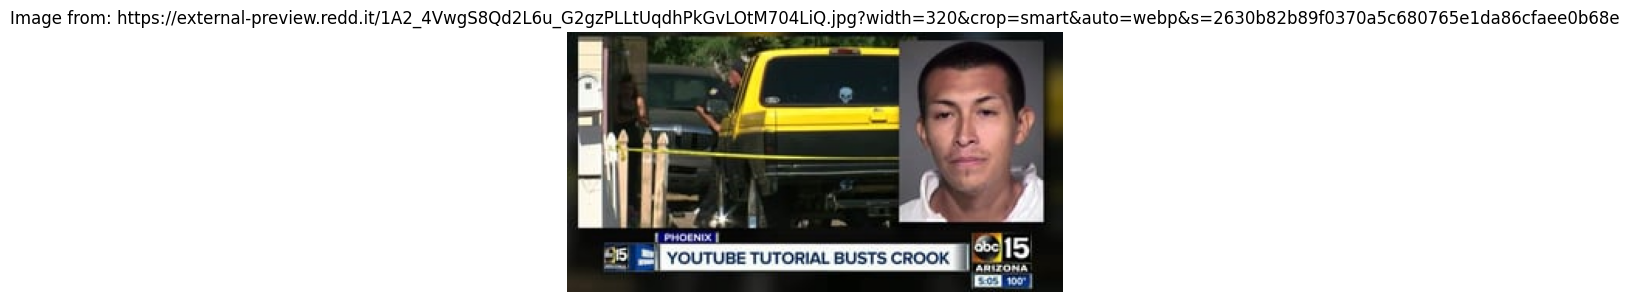

In [ ]:
from PIL import Image
import requests
from io import BytesIO
import matplotlib.pyplot as plt

# Try to display up to 5 images
for i in range(min(15, len(df))):
    url = df["image_url"].iloc[i]
    print(f"Attempting to display image from URL: {url}")

    try:
        response = requests.get(url, timeout=10) # Added timeout
        response.raise_for_status()  # Raise an HTTPError for bad responses (4xx or 5xx)

        img = Image.open(BytesIO(response.content))

        plt.imshow(img)
        plt.axis("off")
        plt.title(f"Image from: {url}")
        plt.show()
        break # Break the loop if an image is successfully displayed
    except requests.exceptions.Timeout:
        print(f"Request timed out for {url}")
    except requests.exceptions.RequestException as e:
        print(f"Error fetching image from {url}: {e}")
    except Image.UnidentifiedImageError:
        print(f"Could not identify image file from {url}. It might be corrupted or not an image.")
    except Exception as e:
        print(f"An unexpected error occurred for {url}: {e}")
else:
    print("No valid image could be displayed from the first 5 URLs.")

200


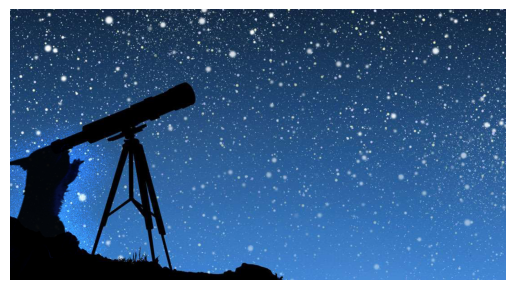

In [ ]:
import requests
from PIL import Image
from io import BytesIO
import matplotlib.pyplot as plt

url = "http://i.imgur.com/BruWKDi.jpg"

headers = {
    "User-Agent": "Mozilla/5.0"
}

response = requests.get(url, headers=headers, timeout=10)

print(response.status_code)

img = Image.open(BytesIO(response.content))

plt.imshow(img)
plt.axis("off")
plt.show()

In [ ]:
df[["clean_title","image_url","2_way_label"]].isnull().sum()

,0
clean_title,0
image_url,156
2_way_label,0


In [ ]:
df["clean_title"].str.len().describe()

,clean_title
count,59319.000000
mean,41.993897
std,31.621703
min,1.000000
25%,19.000000
50%,35.000000
75%,57.000000
max,450.000000


In [ ]:
from urllib.parse import urlparse

df["domain_name"] = df["image_url"].apply(
    lambda x: urlparse(str(x)).netloc
)

df["domain_name"].value_counts().head(10)

,count
domain_name,
external-preview.redd.it,23126
preview.redd.it,18565
i.imgur.com,16669
imgur.com,288
,156
i.redd.it,130
upload.wikimedia.org,13
www.dropbox.com,12
pbs.twimg.com,11
